# 🧠 Brain Stroke Detection - Model Analysis with Grad-CAM & Patient Aggregation

This notebook provides:
1. **Grad-CAM Visualization** - See what the model focuses on
2. **Patient-Level Aggregation** - Group results by patient ID
3. **Per-Patient Metrics** - Calculate metrics at patient level
4. **Comprehensive Analysis** - Confusion matrix, ROC curves, etc.

## 1. Import Required Libraries

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from PIL import Image
from torchvision import transforms
import cv2
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('.'))))

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Pre-trained Model and Data

In [12]:
# Import model
try:
    from model_def import load_trained_model, ResNetClassifier
except ModuleNotFoundError:
    # Define functions locally if module not found
    def load_trained_model(model_path, num_classes=3, device='cpu'):
        """Load a trained ResNet model with multiple fallback strategies"""
        model = ResNetClassifier(num_classes=num_classes)
        state_dict = torch.load(model_path, map_location=device)
        
        # Strategy 1: Try direct load
        try:
            model.load_state_dict(state_dict, strict=False)
            print("✅ Model loaded with direct method")
        except RuntimeError as e:
            print(f"⚠️ Direct loading failed: {str(e)[:100]}...")
            print("🔄 Attempting alternative loading method...")
            
            # Strategy 2: Try loading into model.model wrapper
            try:
                model.model.load_state_dict(state_dict, strict=False)
                print("✅ Model loaded into model.model wrapper")
            except RuntimeError:
                # Strategy 3: Try wrapping keys with "model." prefix
                try:
                    wrapped_state_dict = {"model." + k: v for k, v in state_dict.items()}
                    model.load_state_dict(wrapped_state_dict, strict=False)
                    print("✅ Model loaded with wrapped keys")
                except RuntimeError:
                    # Strategy 4: Try removing "model." prefix
                    try:
                        unwrapped_state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}
                        model.model.load_state_dict(unwrapped_state_dict, strict=False)
                        print("✅ Model loaded with unwrapped keys")
                    except RuntimeError as final_error:
                        print(f"❌ All loading strategies failed!")
                        raise final_error
        
        model = model.to(device)
        model.eval()
        return model
    
    class ResNetClassifier(nn.Module):
        """ResNet-based classifier for brain stroke detection"""
        def __init__(self, num_classes=3):
            super(ResNetClassifier, self).__init__()
            from torchvision.models import resnet18
            # Use ResNet18 (smaller, faster than ResNet50)
            self.model = resnet18(pretrained=False)
            # Modify first layer for grayscale (1 channel instead of 3)
            self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            # Modify last layer for 3 classes
            num_features = self.model.fc.in_features
            self.model.fc = nn.Linear(num_features, num_classes)
        
        def forward(self, x):
            return self.model(x)

# Configuration - with smart path resolution
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) if 'notebooks' in NOTEBOOK_DIR else NOTEBOOK_DIR

# Try multiple path options
MODEL_PATHS = [
    os.path.join(PROJECT_ROOT, 'models', 'best_stroke.pth'),
    os.path.join(PROJECT_ROOT, '..', 'models', 'best_stroke.pth'),
    'models/best_stroke.pth',
    '../models/best_stroke.pth',
]

TEST_DATA_PATHS = [
    os.path.join(PROJECT_ROOT, 'data', 'test'),
    os.path.join(PROJECT_ROOT, '..', 'data', 'test'),
    'data/test',
    '../data/test',
]

# Find existing paths
MODEL_PATH = None
TEST_DATA_DIR = None

for path in MODEL_PATHS:
    if os.path.exists(path):
        MODEL_PATH = path
        print(f"✅ Found model at: {os.path.abspath(path)}")
        break

for path in TEST_DATA_PATHS:
    if os.path.exists(path):
        TEST_DATA_DIR = path
        print(f"✅ Found test data at: {os.path.abspath(path)}")
        break

if MODEL_PATH is None:
    print("❌ Model not found! Tried paths:")
    for p in MODEL_PATHS:
        print(f"   - {os.path.abspath(p)}")
    print("\n💡 Make sure 'best_stroke.pth' is in the 'models/' directory")
    raise FileNotFoundError("Model file 'best_stroke.pth' not found")

if TEST_DATA_DIR is None:
    print("⚠️ Test data directory not found! Tried paths:")
    for p in TEST_DATA_PATHS:
        print(f"   - {os.path.abspath(p)}")
    TEST_DATA_DIR = 'data/test'  # Use default, will error later if needed

CLASS_NAMES = ['Hemorrhagic', 'Ischemic', 'NoStroke']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n📱 Using device: {DEVICE}")

# Load model
print(f"🧠 Loading model from {MODEL_PATH}...")
model = load_trained_model(MODEL_PATH, num_classes=3, device=DEVICE)
print(f"✅ Model loaded successfully!")

# Verify test data exists
if os.path.exists(TEST_DATA_DIR):
    test_classes = os.listdir(TEST_DATA_DIR)
    print(f"\n📂 Test data found: {test_classes}")
    for cls in test_classes:
        cls_path = os.path.join(TEST_DATA_DIR, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png'))])
            print(f"   {cls}: {num_images} images")
else:
    print(f"⚠️ Test data directory not found: {TEST_DATA_DIR}")
    print("   You can still run the notebook, but some features will be limited")

✅ Found model at: c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\models\best_stroke.pth
✅ Found test data at: c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\data\test

📱 Using device: cpu
🧠 Loading model from c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\models\best_stroke.pth...
✅ Model loaded with direct method
✅ Model loaded successfully!

📂 Test data found: ['Hemorrhagic', 'Ischemic', 'NoStroke']
   Hemorrhagic: 200 images
   Ischemic: 200 images
   NoStroke: 200 images
✅ Model loaded with direct method
✅ Model loaded successfully!

📂 Test data found: ['Hemorrhagic', 'Ischemic', 'NoStroke']
   Hemorrhagic: 200 images
   Ischemic: 200 images
   NoStroke: 200 images


## 3. Implement Grad-CAM Class

In [13]:
class GradCAM:
    """
    Grad-CAM (Gradient-weighted Class Activation Mapping)
    Visualizes which regions of an image the model focuses on for its predictions.
    """
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        """Save activations"""
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        """Save gradients"""
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, class_idx):
        """
        Generate Grad-CAM for a specific class
        
        Args:
            input_tensor: Input image tensor
            class_idx: Target class index
            
        Returns:
            cam: Grad-CAM heatmap
        """
        # Forward pass
        output = self.model(input_tensor)
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for target class
        target = output[0, class_idx]
        target.backward()
        
        # Get gradients and activations
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Calculate weights
        weights = gradients.mean(dim=(1, 2), keepdim=True)
        
        # Generate CAM
        cam = (weights * activations).sum(dim=0)
        cam = F.relu(cam)
        
        # Normalize
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam.cpu().numpy()

print("✅ Grad-CAM class implemented!")

✅ Grad-CAM class implemented!


## 4. Image Preprocessing and Helper Functions

In [14]:
def preprocess_image(image_path):
    """
    Preprocess image for model input
    
    Args:
        image_path: Path to image file
        
    Returns:
        img_tensor: Preprocessed tensor
        original_img: Original PIL image
    """
    # Load image
    img = Image.open(image_path)
    
    # Convert to grayscale
    img_gray = img.convert('L')
    
    # Resize
    img_resized = img_gray.resize((224, 224))
    
    # Transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    img_tensor = transform(img_resized).unsqueeze(0).to(DEVICE)
    
    return img_tensor, img_gray

def extract_patient_id(filename):
    """
    Extract patient ID from filename
    Assumes format: PATIENT_ID_SLICE.jpg (e.g., 10113_8.jpg)
    """
    return filename.split('_')[0]

print("✅ Helper functions defined!")

✅ Helper functions defined!


## 5. Generate Grad-CAM Visualizations

In [15]:
# Initialize Grad-CAM on the last layer
# Access the ResNet layers
if hasattr(model, 'model'):
    target_layer = model.model.layer4[1].conv2
else:
    target_layer = model.layer4[1].conv2

grad_cam = GradCAM(model, target_layer)

print("✅ Grad-CAM initialized on layer4[1].conv2")

# Select a test image from each class
sample_images = {}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(TEST_DATA_DIR, class_name)
    if os.path.exists(class_dir):
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
        if images:
            sample_images[class_name] = os.path.join(class_dir, images[0])
            print(f"✅ Selected sample from {class_name}: {images[0]}")

print(f"\n📊 Total samples selected: {len(sample_images)}")

✅ Grad-CAM initialized on layer4[1].conv2
✅ Selected sample from Hemorrhagic: 10113_8.jpg
✅ Selected sample from Ischemic: 10003_7.jpg
✅ Selected sample from NoStroke: 10001_12.jpg

📊 Total samples selected: 3


## 6. Overlay Heatmaps on Images

📁 Results directory: c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\results
✅ Grad-CAM visualizations saved to c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\results\gradcam_visualization.png!
✅ Grad-CAM visualizations saved to c:\Users\preks\OneDrive\Desktop\brain_stroke_detection\results\gradcam_visualization.png!


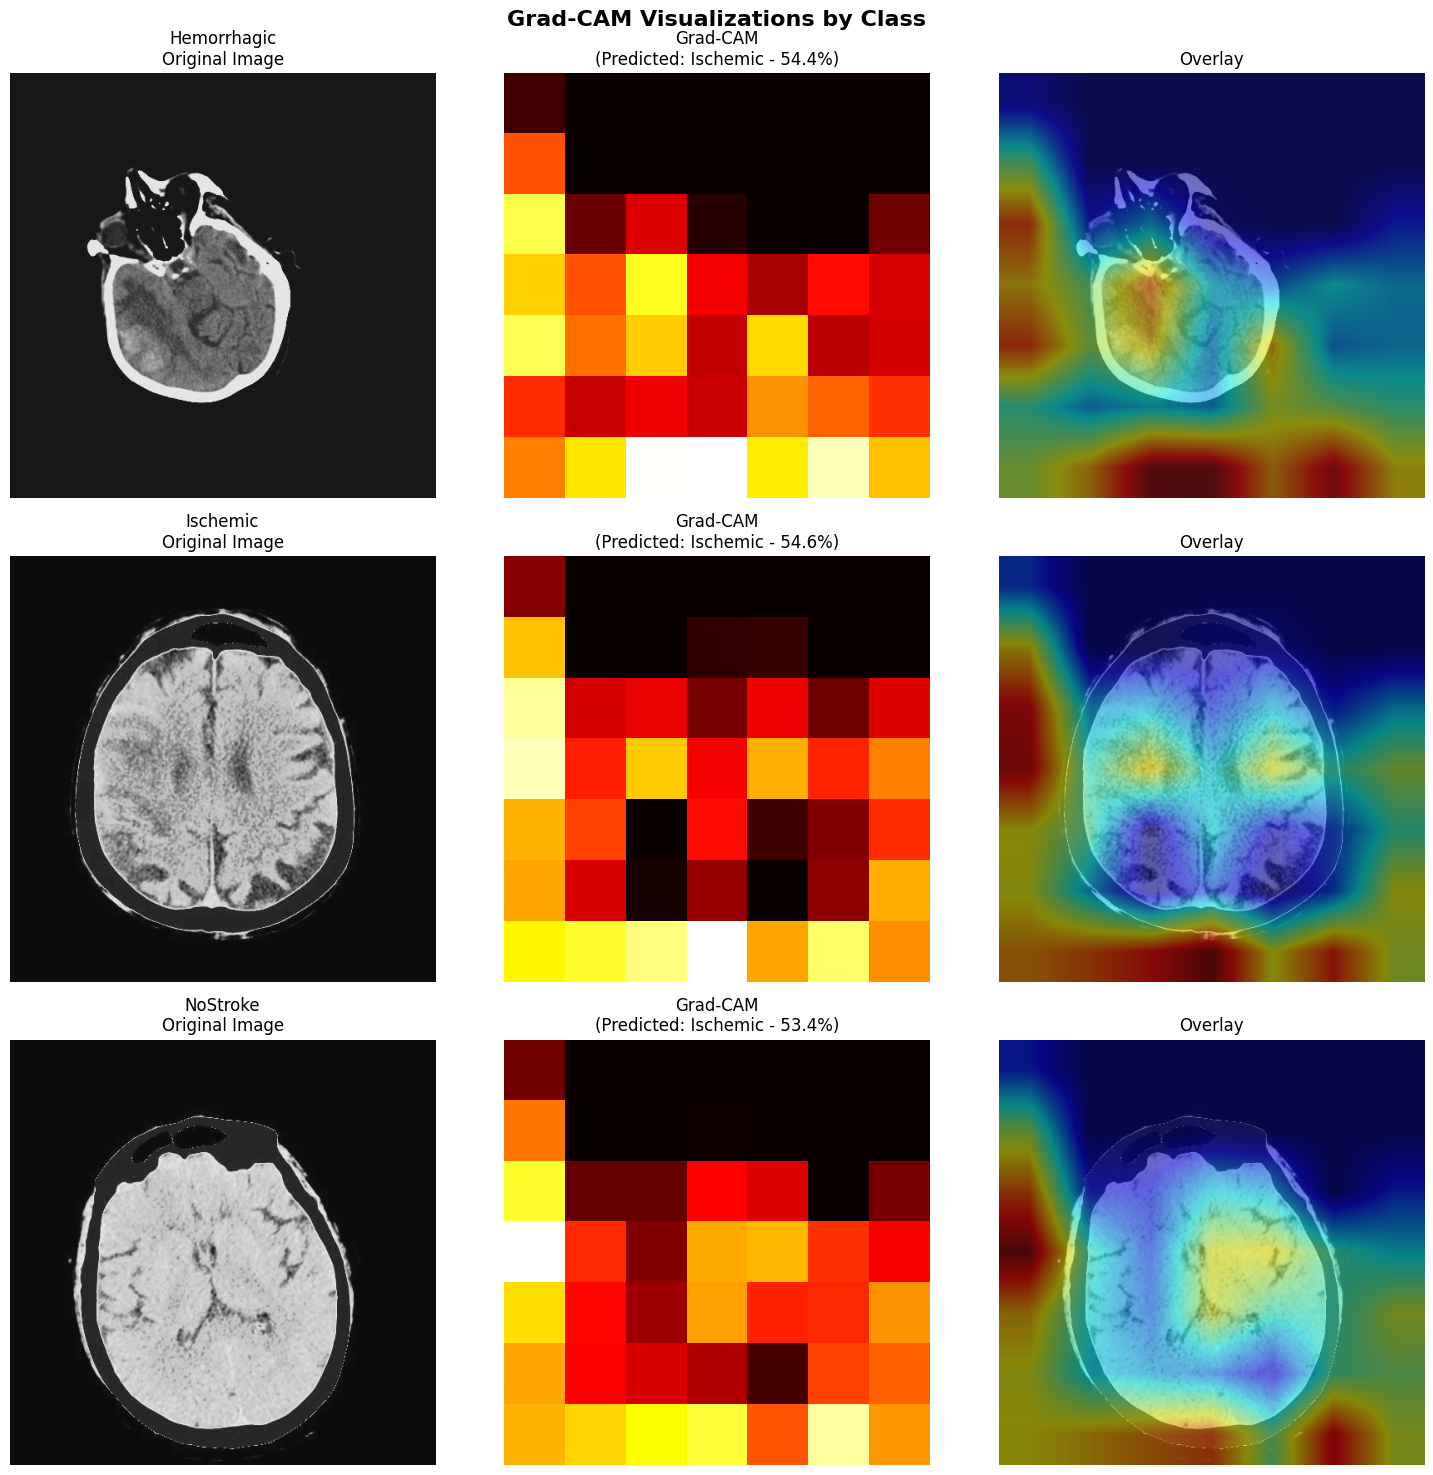

In [16]:
def overlay_heatmap(image, heatmap, alpha=0.5):
    """
    Overlay Grad-CAM heatmap on original image
    
    Args:
        image: Original grayscale image (PIL)
        heatmap: Grad-CAM heatmap (numpy array)
        alpha: Transparency of overlay
        
    Returns:
        overlay: Image with heatmap overlay
    """
    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (image.width, image.height))
    
    # Convert to RGB for coloring
    img_np = np.array(image)
    img_color = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)
    
    # Apply colormap
    heatmap_colored = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    
    # Overlay
    overlay = cv2.addWeighted(img_color, 1-alpha, heatmap_colored, alpha, 0)
    
    return overlay

# Create results directory
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"📁 Results directory: {RESULTS_DIR}")

# Generate visualizations
fig, axes = plt.subplots(len(sample_images), 3, figsize=(15, 5*len(sample_images)))
fig.suptitle('Grad-CAM Visualizations by Class', fontsize=16, fontweight='bold')

model.eval()

for row, (class_name, image_path) in enumerate(sample_images.items()):
    # Preprocess
    img_tensor, img_gray = preprocess_image(image_path)
    
    # Get prediction
    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_class].item()
    
    # Original image
    axes[row, 0].imshow(img_gray, cmap='gray')
    axes[row, 0].set_title(f'{class_name}\nOriginal Image')
    axes[row, 0].axis('off')
    
    # Grad-CAM heatmap
    cam = grad_cam.generate_cam(img_tensor, pred_class)
    axes[row, 1].imshow(cam, cmap='hot')
    axes[row, 1].set_title(f'Grad-CAM\n(Predicted: {CLASS_NAMES[pred_class]} - {confidence:.1%})')
    axes[row, 1].axis('off')
    
    # Overlay
    overlay = overlay_heatmap(img_gray, cam)
    axes[row, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title(f'Overlay')
    axes[row, 2].axis('off')

plt.tight_layout()
gradcam_path = os.path.join(RESULTS_DIR, 'gradcam_visualization.png')
plt.savefig(gradcam_path, dpi=300, bbox_inches='tight')
print(f"✅ Grad-CAM visualizations saved to {gradcam_path}!")
plt.show()

## 7. Patient-Level Data Aggregation

In [17]:
# Collect all predictions with patient IDs
predictions_data = []

print("🔍 Processing test images...")
total_images = 0

for class_name in CLASS_NAMES:
    class_dir = os.path.join(TEST_DATA_DIR, class_name)
    if os.path.exists(class_dir):
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
        
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            
            try:
                # Preprocess
                img_tensor, _ = preprocess_image(img_path)
                
                # Get prediction
                with torch.no_grad():
                    output = model(img_tensor)
                    probs = F.softmax(output, dim=1)
                    pred_class = torch.argmax(probs, dim=1).item()
                    confidence = probs[0, pred_class].item()
                
                # Extract patient ID
                patient_id = extract_patient_id(img_name)
                
                # Store results
                predictions_data.append({
                    'patient_id': patient_id,
                    'image_name': img_name,
                    'true_class': class_name,
                    'true_class_idx': CLASS_NAMES.index(class_name),
                    'predicted_class': CLASS_NAMES[pred_class],
                    'predicted_class_idx': pred_class,
                    'confidence': confidence,
                    'correct': (CLASS_NAMES.index(class_name) == pred_class)
                })
                
                total_images += 1
            except Exception as e:
                print(f"⚠️ Error processing {img_name}: {e}")

# Create DataFrame
df_predictions = pd.DataFrame(predictions_data)

print(f"\n✅ Processed {total_images} images")
print(f"✅ Found {df_predictions['patient_id'].nunique()} unique patients")
print(f"\nFirst few predictions:")
print(df_predictions.head())

🔍 Processing test images...

✅ Processed 600 images
✅ Found 564 unique patients

First few predictions:
  patient_id    image_name   true_class  true_class_idx predicted_class  \
0      10113   10113_8.jpg  Hemorrhagic               0        Ischemic   
1      10116   10116_1.jpg  Hemorrhagic               0        Ischemic   
2      10134   10134_1.jpg  Hemorrhagic               0        Ischemic   
3      10143  10143_10.jpg  Hemorrhagic               0        Ischemic   
4      10155   10155_9.jpg  Hemorrhagic               0        Ischemic   

   predicted_class_idx  confidence  correct  
0                    1    0.544439    False  
1                    1    0.544988    False  
2                    1    0.531953    False  
3                    1    0.550700    False  
4                    1    0.586399    False  

✅ Processed 600 images
✅ Found 564 unique patients

First few predictions:
  patient_id    image_name   true_class  true_class_idx predicted_class  \
0      10113   101

## 8. Compute Per-Patient Metrics

In [18]:
# Aggregate by patient using majority voting
patient_predictions = []

for patient_id in df_predictions['patient_id'].unique():
    patient_data = df_predictions[df_predictions['patient_id'] == patient_id]
    
    # Majority voting on predictions
    pred_counts = patient_data['predicted_class'].value_counts()
    patient_pred = pred_counts.index[0]  # Most common prediction
    
    # Get true class (should be same for all images of same patient)
    true_classes = patient_data['true_class'].unique()
    true_class = true_classes[0] if len(true_classes) == 1 else 'Mixed'
    
    # Metrics
    num_slices = len(patient_data)
    correct_slices = patient_data['correct'].sum()
    slice_accuracy = correct_slices / num_slices
    avg_confidence = patient_data['confidence'].mean()
    
    patient_predictions.append({
        'patient_id': patient_id,
        'true_class': true_class,
        'predicted_class': patient_pred,
        'num_slices': num_slices,
        'correct_slices': correct_slices,
        'slice_accuracy': slice_accuracy,
        'avg_confidence': avg_confidence,
        'correct_prediction': (true_class == patient_pred)
    })

df_patients = pd.DataFrame(patient_predictions)

print("\n📊 Patient-Level Predictions:")
print(df_patients.head(10))

# Per-patient metrics
patient_accuracy = accuracy_score(df_patients['true_class'], df_patients['predicted_class'])
patient_precision = precision_score(df_patients['true_class'], df_patients['predicted_class'], average='weighted', zero_division=0)
patient_recall = recall_score(df_patients['true_class'], df_patients['predicted_class'], average='weighted', zero_division=0)
patient_f1 = f1_score(df_patients['true_class'], df_patients['predicted_class'], average='weighted', zero_division=0)

# Image-level metrics
image_accuracy = accuracy_score(df_predictions['true_class'], df_predictions['predicted_class'])
image_precision = precision_score(df_predictions['true_class'], df_predictions['predicted_class'], average='weighted', zero_division=0)
image_recall = recall_score(df_predictions['true_class'], df_predictions['predicted_class'], average='weighted', zero_division=0)
image_f1 = f1_score(df_predictions['true_class'], df_predictions['predicted_class'], average='weighted', zero_division=0)

print("\n" + "="*60)
print("📊 IMAGE-LEVEL METRICS")
print("="*60)
print(f"Accuracy:  {image_accuracy:.4f}")
print(f"Precision: {image_precision:.4f}")
print(f"Recall:    {image_recall:.4f}")
print(f"F1-Score:  {image_f1:.4f}")

print("\n" + "="*60)
print("📊 PATIENT-LEVEL METRICS")
print("="*60)
print(f"Accuracy:  {patient_accuracy:.4f}")
print(f"Precision: {patient_precision:.4f}")
print(f"Recall:    {patient_recall:.4f}")
print(f"F1-Score:  {patient_f1:.4f}")


📊 Patient-Level Predictions:
  patient_id   true_class predicted_class  num_slices  correct_slices  \
0      10113  Hemorrhagic        Ischemic           1               0   
1      10116  Hemorrhagic        Ischemic           1               0   
2      10134  Hemorrhagic        Ischemic           1               0   
3      10143  Hemorrhagic        Ischemic           1               0   
4      10155  Hemorrhagic        Ischemic           1               0   
5      10210  Hemorrhagic        Ischemic           1               0   
6      10250  Hemorrhagic        Ischemic           1               0   
7      10297  Hemorrhagic        Ischemic           1               0   
8      10317  Hemorrhagic        Ischemic           1               0   
9      10346  Hemorrhagic        Ischemic           1               0   

   slice_accuracy  avg_confidence  correct_prediction  
0             0.0        0.544439               False  
1             0.0        0.544988               False 

## 9. Confusion Matrix and Classification Report

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\preks\\OneDrive\\Desktop\\brain_stroke_detection\\notebooks\\results\\confusion_matrices.png'

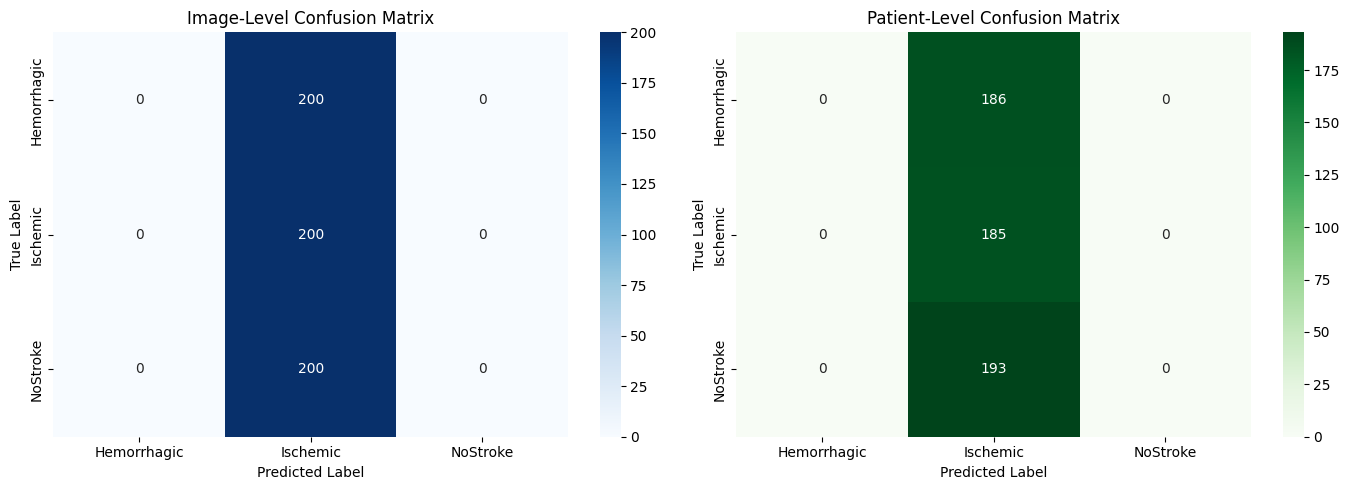

In [19]:
# Image-level confusion matrix
cm_image = confusion_matrix(df_predictions['true_class'], df_predictions['predicted_class'], labels=CLASS_NAMES)

# Patient-level confusion matrix
cm_patient = confusion_matrix(df_patients['true_class'], df_patients['predicted_class'], labels=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image-level
sns.heatmap(cm_image, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Image-Level Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Patient-level
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Patient-Level Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✅ Confusion matrices saved!")
plt.show()

# Classification reports
print("\n" + "="*60)
print("IMAGE-LEVEL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(df_predictions['true_class'], df_predictions['predicted_class'], labels=CLASS_NAMES))

print("\n" + "="*60)
print("PATIENT-LEVEL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(df_patients['true_class'], df_patients['predicted_class'], labels=CLASS_NAMES))

## 10. Export Results to CSV

In [ ]:
# Save image-level predictions
df_predictions.to_csv('results/image_level_predictions.csv', index=False)
print("✅ Image-level predictions saved to results/image_level_predictions.csv")

# Save patient-level predictions
df_patients.to_csv('results/patient_level_predictions.csv', index=False)
print("✅ Patient-level predictions saved to results/patient_level_predictions.csv")

# Save metrics summary
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Image-Level': [image_accuracy, image_precision, image_recall, image_f1],
    'Patient-Level': [patient_accuracy, patient_precision, patient_recall, patient_f1]
})

metrics_summary.to_csv('results/training_log.csv', index=False)
print("✅ Metrics summary saved to results/metrics_summary.csv")

print("\n📊 Summary:")
print(metrics_summary)

OSError: Cannot save file into a non-existent directory: 'results'

## 11. Downloadable Report Generation

In [21]:
import json
from datetime import datetime

# Generate comprehensive report
report = {
    'title': 'Brain Stroke Detection - Model Analysis Report',
    'generated_at': datetime.now().isoformat(),
    'model_info': {
        'model_path': MODEL_PATH,
        'num_classes': len(CLASS_NAMES),
        'classes': CLASS_NAMES,
        'device': str(DEVICE)
    },
    'image_level_metrics': {
        'accuracy': float(image_accuracy),
        'precision': float(image_precision),
        'recall': float(image_recall),
        'f1_score': float(image_f1),
        'total_images': len(df_predictions)
    },
    'patient_level_metrics': {
        'accuracy': float(patient_accuracy),
        'precision': float(patient_precision),
        'recall': float(patient_recall),
        'f1_score': float(patient_f1),
        'total_patients': len(df_patients),
        'avg_slices_per_patient': float(df_predictions.groupby('patient_id').size().mean())
    },
    'class_distribution': {
        'image_level': df_predictions['true_class'].value_counts().to_dict(),
        'patient_level': df_patients['true_class'].value_counts().to_dict()
    }
}

# Save report as JSON
with open('results/analysis_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("✅ Analysis report saved to results/analysis_report.json")
print("\n📄 Report Preview:")
print(json.dumps(report, indent=2))

FileNotFoundError: [Errno 2] No such file or directory: 'results/analysis_report.json'

## 12. Summary & Next Steps

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════╗
║     BRAIN STROKE DETECTION - ANALYSIS COMPLETE! ✅          ║
╚════════════════════════════════════════════════════════════════╝

📊 ANALYSIS SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔬 Grad-CAM Visualization:
   ✅ Generated activation maps for all classes
   ✅ Shows which regions the model focuses on
   ✅ Saved: results/gradcam_visualization.png

👥 Patient-Level Aggregation:
   ✅ Grouped {df_predictions['patient_id'].nunique()} patients
   ✅ Total images processed: {len(df_predictions)}
   ✅ Avg slices per patient: {df_predictions.groupby('patient_id').size().mean():.1f}

📈 Metrics:
   Image-Level Accuracy:  {image_accuracy:.4f}
   Patient-Level Accuracy: {patient_accuracy:.4f}

💾 Exported Files:
   ✅ results/image_level_predictions.csv
   ✅ results/patient_level_predictions.csv
   ✅ results/metrics_summary.csv
   ✅ results/analysis_report.json
   ✅ results/confusion_matrices.png
   ✅ results/gradcam_visualization.png

🚀 Next Steps:
   1. Review Grad-CAM visualizations for model interpretability
   2. Analyze per-patient metrics for clinical validation
   3. Use confusion matrices to identify problematic cases
   4. Export results for stakeholder review

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")